# Hospitalizaciones y defunciones semnales

## Filtrado de los datos

In [2]:
# Importamos las librerias necesarias
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.interpolate import PchipInterpolator

Simbología

- CASOS_SINT = casos sintomáticos
- CASOS_HOSP = casos hospitalizaciones 
- CASOS_DEF = casos defunciones 

In [3]:
df = pd.read_csv("influenza_glm_ready.csv") # Importamos el dataset
influenza = df[['SEMANA_RELATIVA', "CASOS_SINT", "CASOS_HOSP", "CASOS_DEF", 
                'FLAG_SINT', 'FLAG_HOSP','FLAG_DEF']] # Filtramos los datos de nuestro interés.
influenza.head() 

,SEMANA_RELATIVA,CASOS_SINT,CASOS_HOSP,CASOS_DEF,FLAG_SINT,FLAG_HOSP,FLAG_DEF
0,1,134,40,5,observado,observado,observado
1,2,145,62,8,observado,observado,observado
2,3,162,71,9,observado,observado,observado
3,4,125,58,8,observado,observado,observado
4,5,102,49,3,observado,observado,observado


In [4]:
influenza["DEF_ACUMULADAS"] = influenza["CASOS_DEF"].cumsum()

## Inspección de los datos

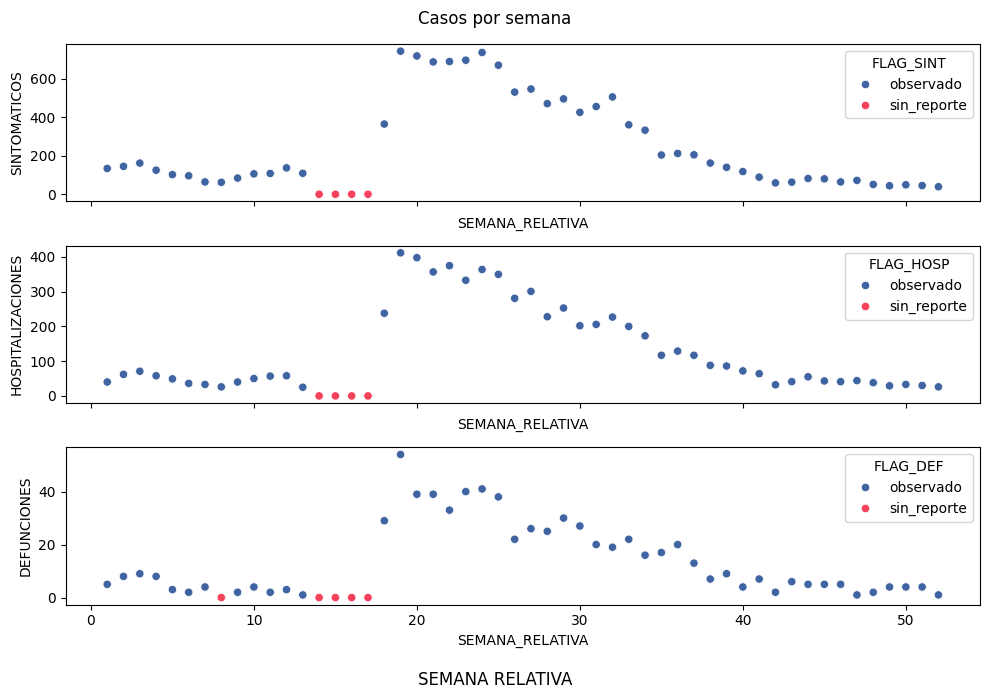

In [62]:
fig, ax = plt.subplots(3, figsize = (10,7))
colors = ['#3f64a1', '#f5425a']

casos =  ["SINT", "HOSP", "DEF"]

for i in range(3):
    sns.scatterplot(
        data=influenza, 
        x = "SEMANA_RELATIVA", 
        y = "CASOS_" + casos[i],
        hue = "FLAG_" + casos[i],
        palette = colors,
        ax = ax[i]
    )
    
fig.supxlabel("SEMANA RELATIVA")

ax[0].set_ylabel("SINTOMATICOS")
ax[1].set_ylabel("HOSPITALIZACIONES")
ax[2].set_ylabel("DEFUNCIONES")

ax[0].set_xticklabels([])
ax[1].set_xticklabels([])

fig.suptitle("Casos por semana")
#fig.text(1,1,"HOla")
plt.tight_layout()
plt.show()

## a) Preprocesamiento

### Semanas con datos faltantes o no reportados

In [6]:
# Filtramos aquellas semanas para las cuales una de las "FLAGS" aparece como no_reportado
NoReportes = influenza[(influenza["FLAG_SINT"] == "sin_reporte") | 
                       (influenza["FLAG_HOSP"] == "sin_reporte") |
                       (influenza["FLAG_DEF"] == "sin_reporte")
]
def resaltar_sin_reporte(val):
    color = 'cyan' if val == 'sin_reporte' else ''
    return f'background-color: {color}'

# Aplicamos los estilos
estilo_final = (
    NoReportes.style
    .hide(axis='index')
    .set_caption("Semanas con al menos uno de los casos etiquetados como sin_reporte")
    .map(resaltar_sin_reporte)
    .set_properties(**{'text-align': 'center'})
    .set_table_styles([
        # Estilo para los encabezados (th)
        dict(selector='th', props=[('text-align', 'center'), ('background-color', '#f2f2f2')]),
        
        # ESTILO PARA EL TÍTULO (caption)
        dict(selector='caption', props=[
            ('font-size', '15px'),    # Aquí ajustas el tamaño (ej. 20px, 1.5em, etc.)
            ('padding', '10px')       # Opcional: espacio entre el título y la tabla
        ])
    ])
)

# Mostrar el resultado
estilo_final

SEMANA_RELATIVA,CASOS_SINT,CASOS_HOSP,CASOS_DEF,FLAG_SINT,FLAG_HOSP,FLAG_DEF,DEF_ACUMULADAS
8,62,26,0,observado,observado,sin_reporte,39
14,0,0,0,sin_reporte,sin_reporte,sin_reporte,51
15,0,0,0,sin_reporte,sin_reporte,sin_reporte,51
16,0,0,0,sin_reporte,sin_reporte,sin_reporte,51
17,0,0,0,sin_reporte,sin_reporte,sin_reporte,51


## b) Modelo 1 - Interpolación

Interpolaremos los datos utilizando un **spline cubico de Hermite**.
Para ello emplearemos la función `PchipInterpolator` de la libreria `SciPy`

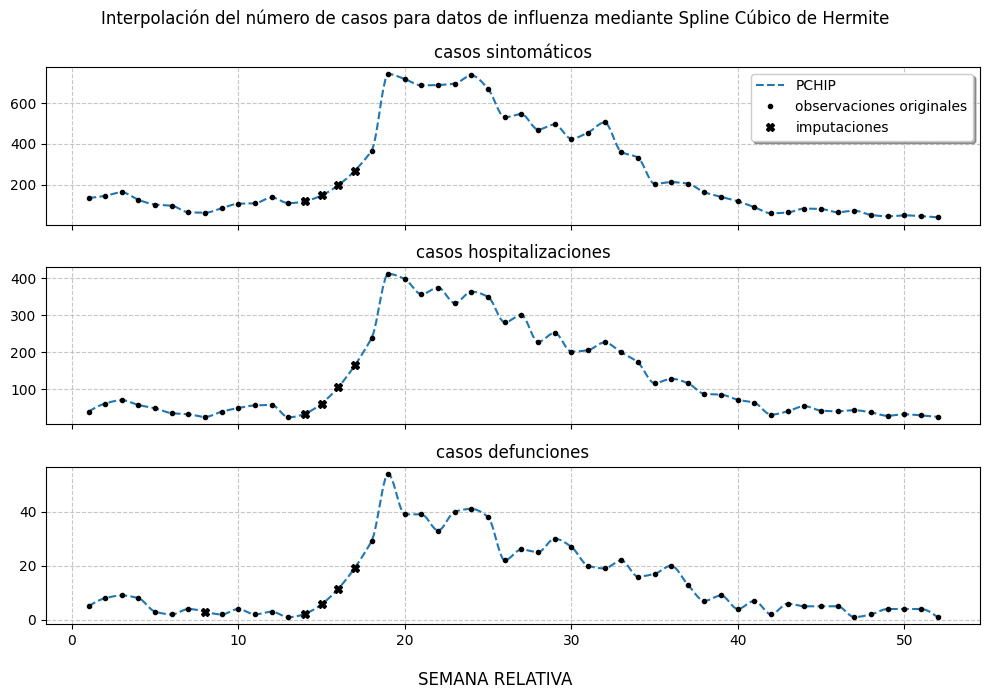

In [63]:
fig, ax = plt.subplots(3, figsize = (10,7))

casos =  ["SINT", "HOSP", "DEF"]
titulos = ["casos sintomáticos", "casos hospitalizaciones", "casos defunciones"]

for i in range(3):
    SemanasConReporte = influenza[influenza["FLAG_" + casos[i]] == "observado"]["SEMANA_RELATIVA"]
    SemanasSinReporte = influenza[influenza["FLAG_" + casos[i]] == "sin_reporte"]["SEMANA_RELATIVA"]
    CasosObservados = influenza[influenza["FLAG_" + casos[i]] == "observado"]["CASOS_" + casos[i]]

    PCHIP = PchipInterpolator(SemanasConReporte, CasosObservados)
    X = np.linspace(1, 52, 7*52)
    Y = PCHIP(X)
    Imputaciones = PCHIP(SemanasSinReporte)

    ax[i].plot(X, Y, '--', label = "PCHIP", )
    ax[i].plot(SemanasConReporte, CasosObservados, 'k.', label='observaciones originales')
    ax[i].plot(SemanasSinReporte, Imputaciones, 'kX', label='imputaciones')
    
    ax[i].grid(True, linestyle='--', alpha=0.7)
    ax[i].set_title(titulos[i])
    ax[i].set_xlabel(None)


fig.supxlabel("SEMANA RELATIVA")
fig.suptitle("Interpolación del número de casos para datos de influenza mediante Spline Cúbico de Hermite")

ax[0].set_xticklabels([])
ax[1].set_xticklabels([])
ax[0].legend(loc='upper right', fancybox=True, shadow=True)
plt.tight_layout()
plt.show() 

### c) Modelo 2 - Regresión Generalizada

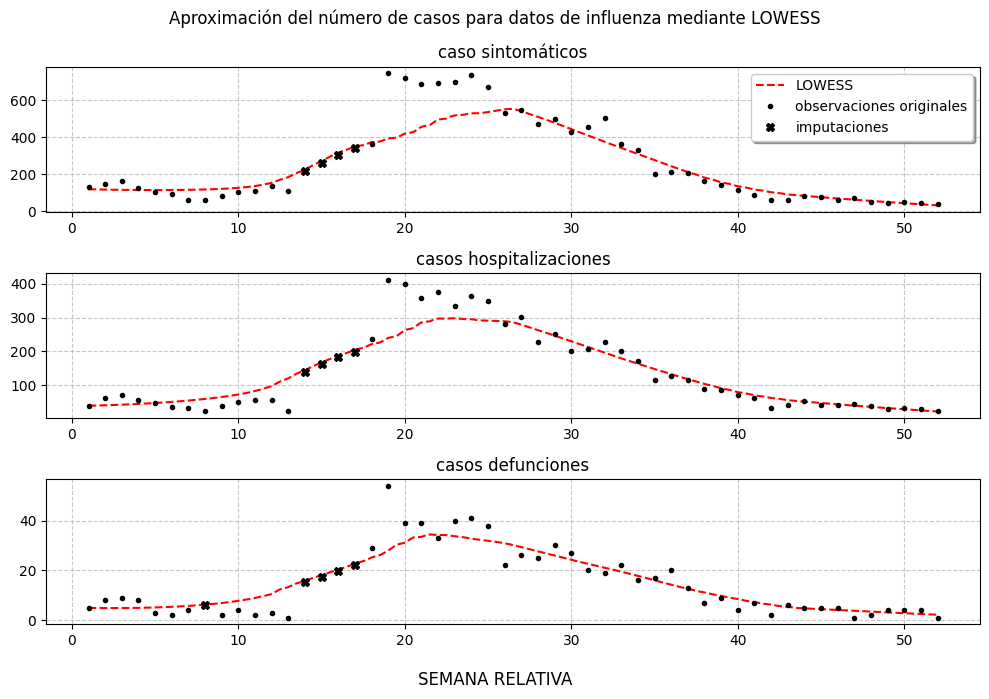

In [66]:
fig, ax = plt.subplots(3, figsize = (10,7))

casos =  ["SINT", "HOSP", "DEF"]
titulos = ["caso sintomáticos", "casos hospitalizaciones", "casos defunciones"]

for i in range(3):
    SemanasConReporte = influenza[influenza["FLAG_" + casos[i]] == "observado"]["SEMANA_RELATIVA"]
    SemanasSinReporte = influenza[influenza["FLAG_" + casos[i]] == "sin_reporte"]["SEMANA_RELATIVA"]
    CasosObservados = influenza[influenza["FLAG_" + casos[i]] == "observado"]["CASOS_" + casos[i]]
    
    X = np.linspace(1, 52, 7*52)
    Regression = lowess(CasosObservados, SemanasConReporte,  xvals=X, frac=0.4)

    ax[i].plot(X, Regression, 'r--', label = "LOWESS", )
    ax[i].plot(SemanasConReporte, CasosObservados, 'k.', label='observaciones originales')
    ax[i].plot(SemanasSinReporte, Regression[7*SemanasSinReporte.index], 'kX', label='imputaciones')

    ax[i].grid(True, linestyle='--', alpha=0.7)
    ax[i].set_title(titulos[i])


fig.supxlabel("SEMANA RELATIVA")
fig.suptitle("Aproximación del número de casos para datos de influenza mediante LOWESS")
ax[0].legend(loc='upper right', fancybox=True, shadow=True)
ax[0].set_xlabel(None)

plt.tight_layout()
plt.show()

    SideQues: Graficar varios lowes para distintos parametros de Frac

In [190]:
Regression[SemanasSinReporte]

array([1.39762079, 2.30275903, 2.45477641, 2.60711263, 2.75976092])

Datos Acumulados

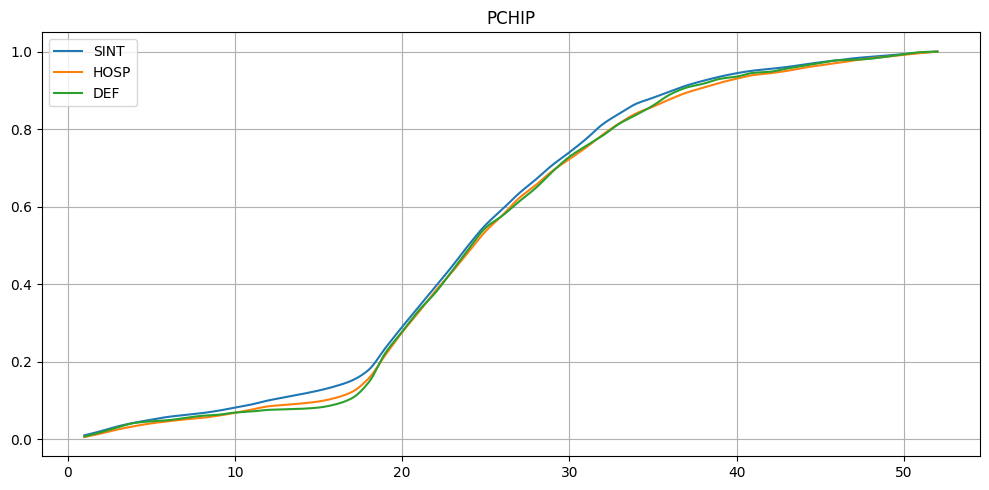

In [87]:
fig, ax = plt.subplots(figsize = (10,5))

for caso in ["SINT", "HOSP", "DEF"]:
    Semanas = influenza["SEMANA_RELATIVA"]
    Casos = influenza["CASOS_" + caso].astype(float)
    CasosObservados = influenza[influenza["FLAG_" + caso] == "observado"]["CASOS_" + caso]
    SemanasReporte = influenza[influenza["FLAG_" + caso] == "observado"]["SEMANA_RELATIVA"]
    SemanasSinReporte = influenza[influenza["FLAG_" + caso] == "sin_reporte"]["SEMANA_RELATIVA"]
                                                                              
    Poly = PchipInterpolator(SemanasReporte, CasosObservados)

    Casos[SemanasSinReporte.index] = Poly(SemanasSinReporte.index)
    CasosAcumulados = [Casos[0]]

    for i in range(1, 52):
        CasosAcumulados.append(CasosAcumulados[i-1]+Casos[i])

    CasosAcumulados  = np.array(CasosAcumulados)
    CasosAcumulados = CasosAcumulados / CasosAcumulados[-1]

    PolyAcumulado = PchipInterpolator(Semanas, CasosAcumulados)
    X = np.linspace(1, 52, 7*52)
    Y = PolyAcumulado(X)
    Imputaciones = PolyAcumulado(SemanasSinReporte)
    ax.plot(X, Y, label=caso)
    #ax.plot(SemanasSinReporte, Imputaciones, 'k+')

ax.set_title("PCHIP")
plt.tight_layout()
plt.grid(True)
plt.legend()
plt.show()

Añadir los datos del interpolador

### Sidequest 1
Ajustar con aproximadores macanisticos

### Sidequest 2 

Investigar como predecir un modelo binomial dados cofactores usnado glm

Hacer un glm con una variable binomial para predecir defunciones dado cofactores/predictores: prop_ (proporciones)
p (muerte|covariable) = ?
- Edad, etc